<a href="https://colab.research.google.com/github/Kethellem/cursopython/blob/main/Redu%C3%A7%C3%A3o_da_Dimensionalidade.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Year_Birth         2240 non-null   int64  
 1   Education          2240 non-null   object 
 2   Marital_Status     2240 non-null   object 
 3   Income             2216 non-null   float64
 4   Kidhome            2240 non-null   int64  
 5   Recency            2240 non-null   int64  
 6   MntWines           2240 non-null   int64  
 7   MntFruits          2240 non-null   int64  
 8   MntMeatProducts    2240 non-null   int64  
 9   MntFishProducts    2240 non-null   int64  
 10  MntSweetProducts   2240 non-null   int64  
 11  MntGoldProds       2240 non-null   int64  
 12  NumStorePurchases  2240 non-null   int64  
 13  NumWebVisitsMonth  2240 non-null   int64  
 14  Complain           2240 non-null   int64  
 15  WebPurchases       2240 non-null   int64  
dtypes: float64(1), int64(13)

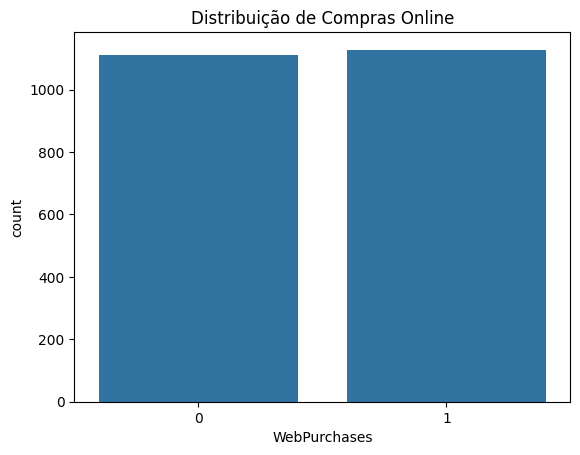

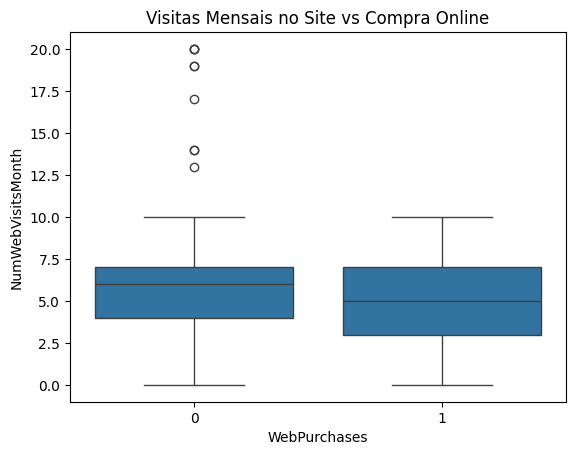

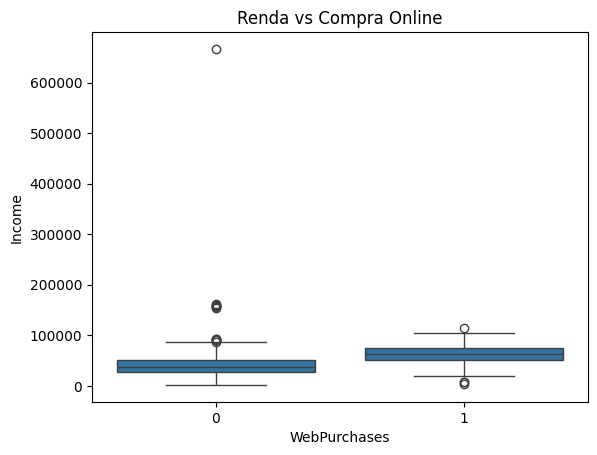

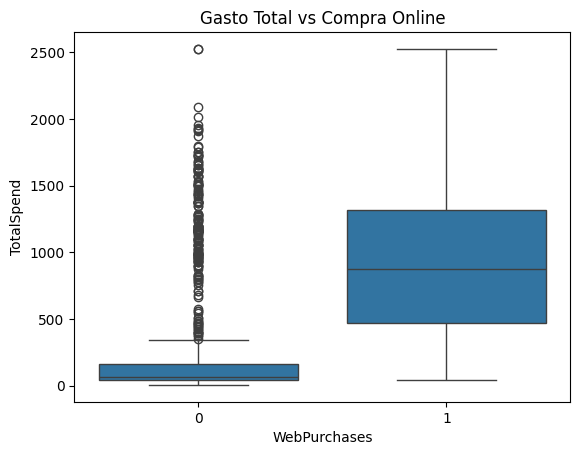

<class 'pandas.core.frame.DataFrame'>
Index: 2217 entries, 0 to 2239
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Education          2217 non-null   object 
 1   Marital_Status     2217 non-null   object 
 2   Income             2217 non-null   float64
 3   Kidhome            2217 non-null   int64  
 4   Recency            2217 non-null   int64  
 5   MntWines           2217 non-null   int64  
 6   MntFruits          2217 non-null   int64  
 7   MntMeatProducts    2217 non-null   int64  
 8   MntFishProducts    2217 non-null   int64  
 9   MntSweetProducts   2217 non-null   int64  
 10  MntGoldProds       2217 non-null   int64  
 11  NumStorePurchases  2217 non-null   int64  
 12  NumWebVisitsMonth  2217 non-null   int64  
 13  Complain           2217 non-null   int64  
 14  WebPurchases       2217 non-null   int64  
 15  Age                2217 non-null   int64  
 16  TotalSpend         2217 non-n

,Education,Marital_Status,Income,Kidhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumStorePurchases,NumWebVisitsMonth,Complain,WebPurchases,Age,TotalSpend,HasChildren
0,Graduation,Single,58138.0,0,58,635,88,546,172,88,88,4,7,0,1,69,1617,0
1,Graduation,Single,46344.0,1,38,11,1,6,2,1,6,2,5,0,0,72,27,1
2,Graduation,Together,71613.0,0,26,426,49,127,111,21,42,10,4,0,1,61,776,0
3,Graduation,Together,26646.0,1,26,11,4,20,10,3,5,4,6,0,0,42,53,1
4,PhD,Married,58293.0,1,94,173,43,118,46,27,15,6,5,0,1,45,422,1


In [24]:

# PREPARAÇÃO, EXPLORAÇÃO E LIMPEZA DOS DADOS
# Objetivo: preparar os dados para prever INTENÇÃO DE COMPRA
# Variável alvo (target): WebPurchases
# ============================================================

# IMPORTAÇÃO DAS BIBLIOTECAS

# pandas: análise e manipulação de dados
import pandas as pd

# numpy: operações matemáticas
import numpy as np

# bibliotecas para visualização
import matplotlib.pyplot as plt
import seaborn as sns


# CARREGAMENTO DO DATASET

# Leitura do arquivo CSV
# OBS: o separador do arquivo é ";"
df = pd.read_csv("marketing_campaign.csv", sep=";")

# Visualização rápida
df.head()


# EXPLORAÇÃO INICIAL DOS DADOS

# Dimensão do dataset (linhas, colunas)
df.shape

# Informação geral: tipos de dados, valores nulos
df.info()

# Estatísticas descritivas das variáveis numéricas
df.describe().T


# CONFERÊNCIA DAS COLUNAS
# (passo essencial para evitar KeyError)

df.columns

# ANÁLISE E TRATAMENTO DE VALORES AUSENTE
# Verificando valores nulos por coluna
df.isnull().sum()

# Tratamento da variável Income
# Estratégia: substituir valores nulos pela mediana
df["Income"] = df["Income"].fillna(df["Income"].median())

# Verificação após tratamento
df["Income"].isnull().sum()


# LIMPEZA DAS VARIÁVEIS CATEGÓRICAS
# Análise da distribuição das categorias
df["Education"].value_counts()
df["Marital_Status"].value_counts()

# Tratamento de categorias inconsistentes em Marital_Status
# Categorias como YOLO e Absurd são agrupadas como "Single"
df["Marital_Status"] = df["Marital_Status"].replace(
    ["YOLO", "Absurd"], "Single"
)

# Conferência pós-tratamento
df["Marital_Status"].value_counts()


# ENGENHARIA DE ATRIBUTOS
#  Idade do cliente

# Cálculo da idade a partir do ano de nascimento
df["Age"] = 2026 - df["Year_Birth"]

# Remoção da coluna original por ser redundante
df = df.drop(columns=["Year_Birth"])


# Gasto total do cliente

# Soma de todos os gastos monetários
df["TotalSpend"] = (
    df["MntWines"] +
    df["MntFruits"] +
    df["MntMeatProducts"] +
    df["MntFishProducts"] +
    df["MntSweetProducts"] +
    df["MntGoldProds"]
)


#Presença de filhos

# Criação de variável binária indicando se o cliente tem filhos
df["HasChildren"] = np.where(df["Kidhome"] > 0, 1, 0)


# ANÁLISE EXPLORATÓRIA (FOCO EM INTENÇÃO DE COMPRA)

# Variável alvo
target = "WebPurchases"

# Distribuição da variável alvo
sns.countplot(x=target, data=df)
plt.title("Distribuição de Compras Online")
plt.show()


#Visitas ao site vs compra online
sns.boxplot(x=target, y="NumWebVisitsMonth", data=df)
plt.title("Visitas Mensais no Site vs Compra Online")
plt.show()


# Renda vs compra online
sns.boxplot(x=target, y="Income", data=df)
plt.title("Renda vs Compra Online")
plt.show()


# Gasto total vs compra online
sns.boxplot(x=target, y="TotalSpend", data=df)
plt.title("Gasto Total vs Compra Online")
plt.show()


#  TRATAMENTO DE OUTLIERS
# Remoção dos 1% maiores valores de renda

limite_superior = df["Income"].quantile(0.99)
df = df[df["Income"] <= limite_superior]


# VALIDAÇÃO FINAL DO DATASET

# Estrutura final da base
df.info()

# Estatísticas finais
df.describe().T

# Visualização final
df.head()



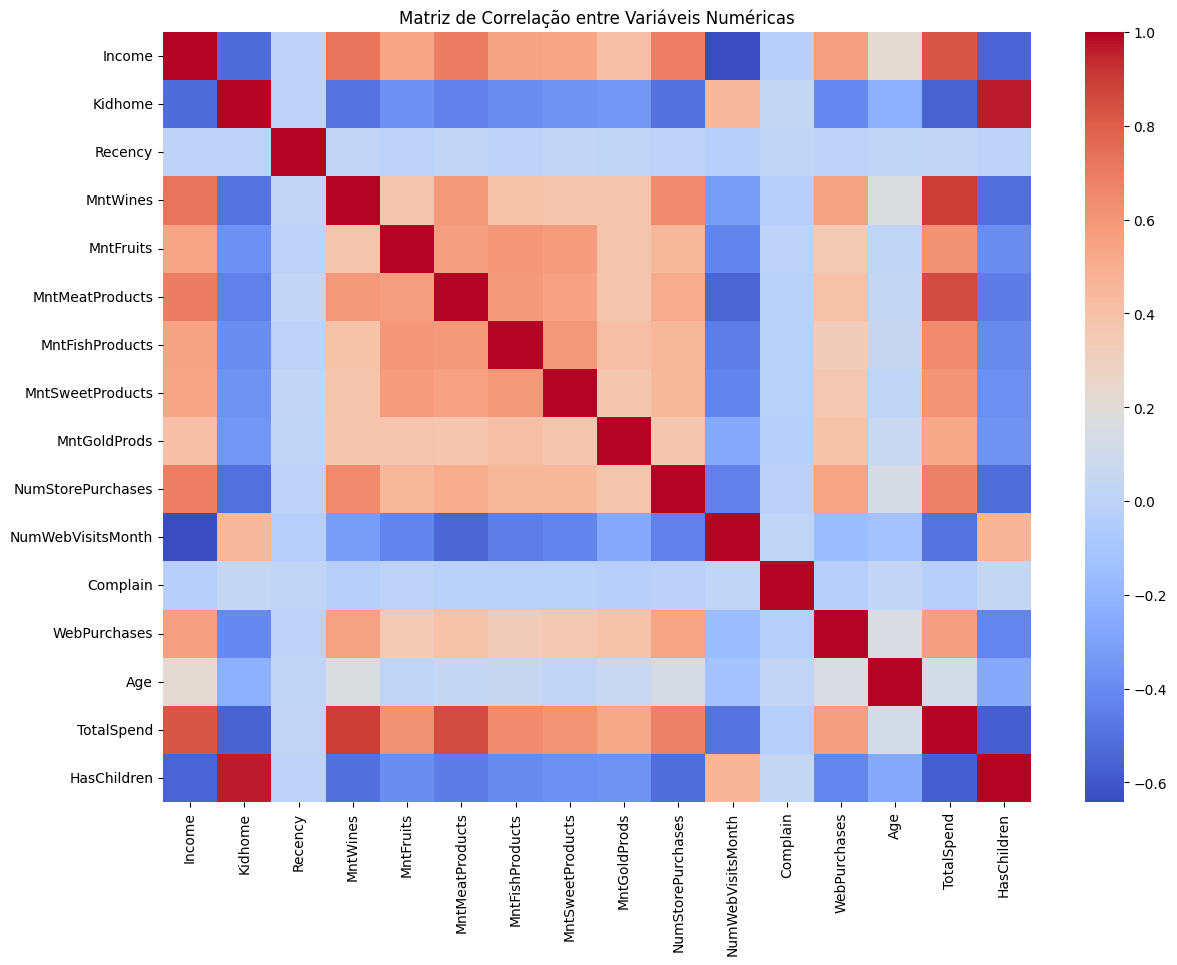

Dimensão X_train: (1551, 23)
Dimensão X_test: (666, 23)
Dimensão y_train: (1551,)
Dimensão y_test: (666,)


In [25]:
# PRÉ-PROCESSAMENTO DOS DADOS
# Objetivo: deixar os dados prontos para Machine Learning
# ============================================================


# BIBLIOTECAS NECESSÁRIAS

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# DEFINIÇÃO DA VARIÁVEL ALVO


# Variável que representa a intenção de compra online
target = "WebPurchases"


#  ANÁLISE DE CORRELAÇÃO

# Aqui avaliamos:
# - quais variáveis se relacionam com a intenção de compra
# - multicolinearidade entre variáveis explicativas


# Seleciona apenas colunas numéricas
df_numeric = df.select_dtypes(include=["int64", "float64"])

# Matriz de correlação
corr_matrix = df_numeric.corr()

# Visualização da matriz de correlação
plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    annot=False,
    fmt=".2f"
)
plt.title("Matriz de Correlação entre Variáveis Numéricas")
plt.show()


# CORRELAÇÃO COM A VARIÁVEL ALVO

# Avalia quais atributos têm maior relação com WebPurchases

corr_target = corr_matrix[target].sort_values(ascending=False)

corr_target


# ANÁLISE CRÍTICA DAS VARIÁVEIS
# ------------------------------
# A partir da correlação, algumas variáveis costumam ter
# influência muito baixa no target e podem ser removidas
#
# Exemplo típico de variáveis fracas:
# - Complain (normalmente quase sempre zero)
# - Recency (dependendo da análise)
#
# OBS: a remoção ajuda a simplificar o modelo


# Lista manual de variáveis pouco informativas (análise conceitual)
variaveis_pouco_importantes = ["Complain"]

# Remove apenas se existirem no DataFrame
df = df.drop(columns=[col for col in variaveis_pouco_importantes if col in df.columns])


#  CODIFICAÇÃO DE VARIÁVEIS CATEGÓRICAS

# Machine Learning não trabalha com texto
# Vamos usar One-Hot Encoding (get_dummies)

categorical_cols = ["Education", "Marital_Status"]

df_encoded = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True  # evita multicolinearidade
)


# SEPARAÇÃO ENTRE X (features) E y (target)


X = df_encoded.drop(columns=[target])
y = df_encoded[target]


#  SEPARAÇÃO EM TREINO E TESTE

# Mantemos 30% da base para teste
# Stratify mantém a proporção da variável alvo

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)


# PADRONIZAÇÃO DOS DADOS

# A padronização é essencial para:
# - regressão logística
# - SVM
# - KNN
# - redes neurais
#
# O scaler é ajustado SOMENTE nos dados de treino

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# VERIFICAÇÃO FINAL


print("Dimensão X_train:", X_train_scaled.shape)
print("Dimensão X_test:", X_test_scaled.shape)
print("Dimensão y_train:", y_train.shape)
print("Dimensão y_test:", y_test.shape)


MODELO: Logistic Regression
              precision    recall  f1-score   support

           0       0.87      0.85      0.86       332
           1       0.85      0.87      0.86       334

    accuracy                           0.86       666
   macro avg       0.86      0.86      0.86       666
weighted avg       0.86      0.86      0.86       666



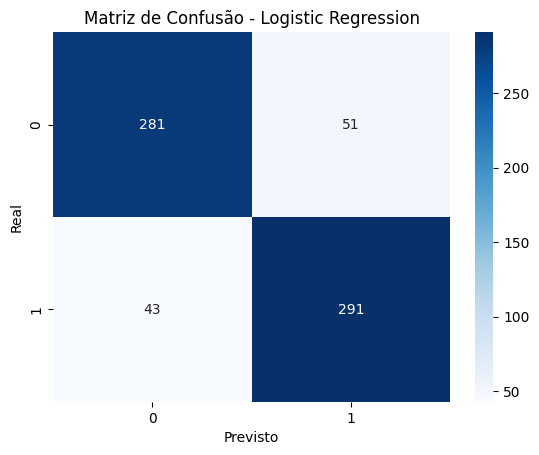

MODELO: Random Forest
              precision    recall  f1-score   support

           0       0.95      0.86      0.90       332
           1       0.87      0.96      0.91       334

    accuracy                           0.91       666
   macro avg       0.91      0.91      0.91       666
weighted avg       0.91      0.91      0.91       666



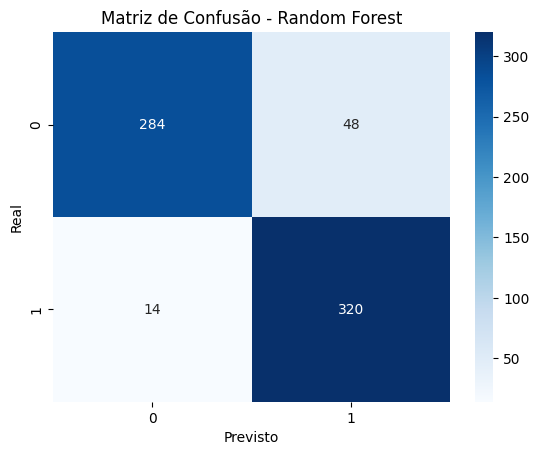

MODELO: Gradient Boosting
              precision    recall  f1-score   support

           0       0.95      0.87      0.91       332
           1       0.88      0.96      0.92       334

    accuracy                           0.91       666
   macro avg       0.92      0.91      0.91       666
weighted avg       0.92      0.91      0.91       666



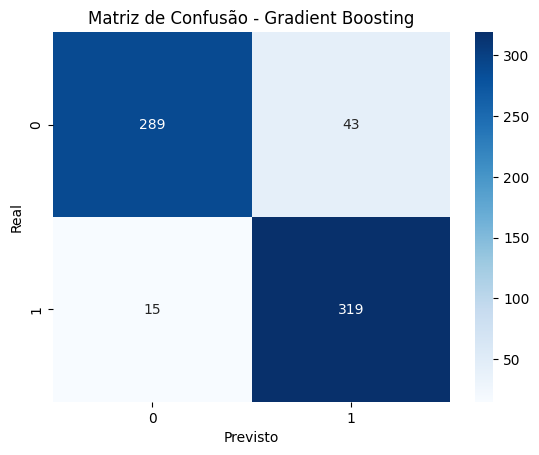

,Model,ROC_AUC
2,Gradient Boosting,0.968112
1,Random Forest,0.962863
0,Logistic Regression,0.903073


In [26]:
#  MODELAGEM (CLASSIFICAÇÃO BINÁRIA)
# Objetivo: prever intenção de compra (WebPurchases)

 # IMPORTAÇÃO DAS BIBLIOTECAS


from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


# DEFINIÇÃO DOS MODELOS

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        random_state=42
    )
}


#  TREINAMENTO E AVALIAÇÃO


results = []

for model_name, model in models.items():

    # Treinamento
    model.fit(X_train_scaled, y_train)

    # Previsões
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    # Métrica principal para classificação binária
    roc_auc = roc_auc_score(y_test, y_proba)

    # Armazenando resultados
    results.append({
        "Model": model_name,
        "ROC_AUC": roc_auc
    })

    # Relatório detalhado
    print("=" * 60)
    print(f"MODELO: {model_name}")
    print("=" * 60)
    print(classification_report(y_test, y_pred))

    # Matriz de confusão
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Matriz de Confusão - {model_name}")
    plt.xlabel("Previsto")
    plt.ylabel("Real")
    plt.show()


# COMPARAÇÃO FINAL ENTRE MODELOS


results_df = pd.DataFrame(results).sort_values(by="ROC_AUC", ascending=False)

results_df

**Avaliação dos resultados dos modelos**

Nesta etapa, foram testados três modelos para prever se um cliente iria ou não realizar uma compra online. Os modelos avaliados foram: Regressão Logística, Random Forest e Gradient Boosting.
Para comparar os modelos, foram utilizadas métricas clássicas de classificação, como acurácia, precisão, recall e ROC-AUC, além da matriz de confusão, que ajuda a entender melhor os acertos e erros do modelo.
De forma geral, o Gradient Boosting apresentou os melhores resultados. Ele obteve o maior valor de ROC-AUC, o que indica que esse modelo consegue distinguir melhor os clientes que compram dos que não compram. Além disso, apresentou alta acurácia, mostrando que a maior parte das previsões foi feita corretamente.
Ao analisar a matriz de confusão do modelo Gradient Boosting, observa-se que:

A maioria dos clientes que realmente compraram foi corretamente identificada pelo modelo (verdadeiros positivos).
Poucos clientes compradores foram classificados incorretamente como não compradores (falsos negativos).
Houve alguns casos em que o modelo indicou compra, mas o cliente não comprou (falsos positivos), o que é aceitável em um contexto de marketing.

Esse comportamento é desejável, pois é melhor tentar oferecer produtos a alguns clientes que talvez não comprem do que deixar de identificar clientes que têm grande chance de compra.
Comparando com os outros modelos:

A Regressão Logística teve desempenho inferior, principalmente por não captar tão bem relações mais complexas entre as variáveis.
O Random Forest teve resultados bons, mas ainda ficou levemente abaixo do Gradient Boosting.

**Conclusão**

Com base nas métricas de avaliação e na análise da matriz de confusão, o Gradient Boosting foi o modelo que melhor realizou as previsões. Ele apresentou maior capacidade de identificar corretamente os clientes com intenção de compra, sendo o mais indicado para apoiar decisões de marketing e estratégias de venda online.